In [2]:
import pandas  as pd

In [3]:
df = pd.read_csv("../data/raw/tmdb_movies.csv")

In [6]:
df.head(5)

,id,title,overview,genres,release_date,vote_average,popularity
0,969681,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,Science Fiction|Action|Adventure,2026-07-29,7.865,839.8385
1,1204680,Coyote vs. Acme,After Acme products fail him one too many time...,Comedy|Adventure|Family,2026-08-20,7.685,654.7252
2,1368337,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",Adventure|Action|Fantasy,2026-07-15,7.998,464.1594
3,1288445,Mutiny,After witnessing his billionaire boss' murder ...,Action|Thriller,2026-08-19,6.382,408.1873
4,1375646,Colony,Professor Se-jeong is thrust into a bloody nig...,Action|Horror|Science Fiction,2026-05-21,8.098,318.9049


In [7]:
df.shape

(10000, 7)

In [9]:
df.columns

Index(['id', 'title', 'overview', 'genres', 'release_date', 'vote_average',
       'popularity'],
      dtype='object')

In [10]:
df.dtypes

id                int64
title            object
overview         object
genres           object
release_date     object
vote_average    float64
popularity      float64
dtype: object

In [12]:
df.describe

<bound method NDFrame.describe of            id                       title  \
0      969681   Spider-Man: Brand New Day   
1     1204680             Coyote vs. Acme   
2     1368337                 The Odyssey   
3     1288445                      Mutiny   
4     1375646                      Colony   
...       ...                         ...   
9995   939159  Jitsuroku Yozakura Ginji 2   
9996  1756247              STARTING FIRES   
9997   651114                  Underwater   
9998    73065                The Humanoid   
9999   910691   Enomoto's Heaven and Hell   

                                               overview  \
0     Fighting crime full-time as Spider-Man in a wo...   
1     After Acme products fail him one too many time...   
2     Odysseus, the legendary King of Ithaca, embark...   
3     After witnessing his billionaire boss' murder ...   
4     Professor Se-jeong is thrust into a bloody nig...   
...                                                 ...   
9995        

In [13]:
df.describe()

,id,vote_average,popularity
count,1.000000e+04,10000.000000,10000.000000
mean,4.824564e+05,5.814911,9.464757
std,5.106798e+05,2.443781,16.648932
min,5.000000e+00,0.000000,2.123900
25%,1.428725e+04,5.719750,5.231200
50%,3.333480e+05,6.528000,6.728450
75%,8.320250e+05,7.184000,9.879150
max,1.765072e+06,10.000000,839.838500


In [14]:
df.isnull().sum()

id                0
title             0
overview        333
genres          522
release_date     42
vote_average      0
popularity        0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(284)

In [17]:
df["id"].duplicated().sum()

np.int64(305)

genres
Drama                    822
Comedy                   413
Drama|Romance            262
Documentary              190
Horror                   178
Horror|Thriller          155
Comedy|Drama             151
Comedy|Romance           138
Action|Thriller          122
Romance|Drama            108
Drama|History             96
Drama|Thriller            96
Action|Crime|Thriller     94
Crime|Drama               86
Action|Crime|Drama        81
Drama|Comedy              76
Crime|Drama|Thriller      75
Action|Crime              70
Horror|Mystery            68
Action                    68
Name: count, dtype: int64

In [ ]:
df["genres"].value_counts().head(20)

In [20]:
genre_counts = (
    df["genres"]
    .dropna()
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts

genres
Drama              4085
Comedy             2634
Action             2617
Thriller           2277
Crime              1616
Adventure          1577
Romance            1256
Horror             1171
Science Fiction    1131
Fantasy            1059
Animation          1043
Family              962
Mystery             719
History             428
War                 288
Documentary         257
Music               225
Western             119
TV Movie            114
Name: count, dtype: int64

In [21]:
df["overview_length"] = df["overview"].fillna("").str.split().str.len()

In [22]:
df["overview_length"].describe()

count    10000.000000
mean        44.186400
std         26.355662
min          0.000000
25%         26.000000
50%         39.000000
75%         59.000000
max        188.000000
Name: overview_length, dtype: float64

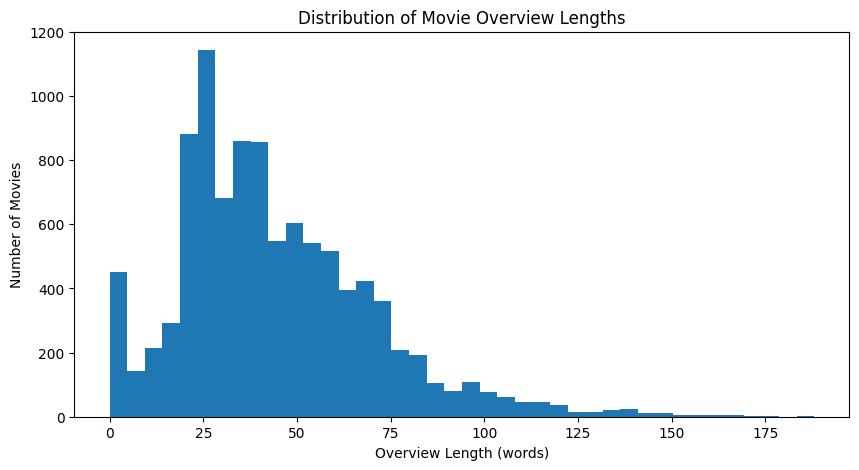

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["overview_length"], bins=40)

plt.xlabel("Overview Length (words)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Overview Lengths")

plt.show()

In [24]:
df["genre_count"] = df["genres"].fillna("").str.split("|").str.len()

In [25]:
df["genre_count"].value_counts().sort_index()

genre_count
1    2456
2    2840
3    3318
4     995
5     319
6      69
7       3
Name: count, dtype: int64

In [26]:
df[df["overview"].isna() & df["genres"].isna()].shape

(124, 9)

In [28]:
pd.crosstab(
    df["overview"].isna(),
    df["genres"].isna(),
    rownames=["Overview Missing"],
    colnames=["Genres Missing"]
)

Genres Missing,False,True
Overview Missing,,
False,9269,398
True,209,124


In [29]:
df[df["id"].duplicated(keep=False)].sort_values("id").head(20)

,id,title,overview,genres,release_date,vote_average,popularity,overview_length,genre_count
9697,136,Freaks,A circus' beautiful trapeze artist agrees to m...,Drama|Horror,1932-01-01,7.769,5.2434,26,2
9700,136,Freaks,A circus' beautiful trapeze artist agrees to m...,Drama|Horror,1932-01-01,7.769,5.2434,26,2
4819,179,The Interpreter,"After Silvia Broome, an interpreter at United ...",Crime|Thriller,2005-04-08,6.315,7.2788,23,2
4820,179,The Interpreter,"After Silvia Broome, an interpreter at United ...",Crime|Thriller,2005-04-08,6.314,7.2788,23,2
8497,219,Volver,Three generations of women deal with family se...,Comedy|Drama|Romance,2006-03-17,7.461,5.7393,20,3
7839,219,Volver,Three generations of women deal with family se...,Comedy|Drama|Romance,2006-03-17,7.461,5.7393,20,3
999,242,The Godfather Part III,In the midst of trying to legitimize his busin...,Crime|Drama|Thriller,1990-12-25,7.418,15.4662,34,3
1001,242,The Godfather Part III,In the midst of trying to legitimize his busin...,Crime|Drama|Thriller,1990-12-25,7.418,15.4662,34,3
7174,326,Snakes on a Plane,FBI agent Neville Flynn boards a flight from H...,Action|Adventure|Crime|Horror|Thriller,2006-08-17,5.479,6.3302,64,5
6965,326,Snakes on a Plane,FBI agent Neville Flynn boards a flight from H...,Action|Adventure|Crime|Thriller,2006-08-17,5.500,6.3302,64,4


In [30]:
df["id"].nunique()

9695

In [31]:
len(df) - df["id"].nunique()

305

In [32]:
df["genres_normalized"] = (
    df["genres"]
    .dropna()
    .apply(lambda x: "|".join(sorted(x.split("|"))))
)

In [33]:
df["genres_normalized"].nunique(), df["genres"].nunique()

(882, 1944)